# 04 — Baseline Models, Evaluation & Comparison
**Project:** AI-Powered Essay Evaluation & Writing Assistant — Review 1

This is the final Review 1 notebook. It covers Steps 7-10:
1. Train/test split (80/20)
2. TF-IDF fit **after** the split (no data leakage)
3. Three baseline regressors on two feature sets (TF-IDF, handcrafted NLP features)
4. Regression evaluation: MAE, MSE, RMSE, R²
5. Secondary Low/Medium/High classification experiment (confusion matrix requirement)
6. Final model comparison and the correct way to pick a "best" baseline

The notebook loads only the columns required for this baseline pipeline, rather than unnecessarily
loading the large source-text and demographic columns.


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../src')

from models.baseline_models import get_baseline_regressors, get_baseline_classifier, train_and_time
from models.evaluate import regression_metrics, classification_metrics, plot_confusion_matrix
from data.preprocess import add_score_category_column

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

PROCESSED_PATH = '../data/processed/essays_processed.csv'
FIG_DIR = '../results/figures'
METRICS_DIR = '../results/metrics'

RANDOM_STATE = 42

# Create output folders if they do not already exist
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# Read only the header first so we know exactly which columns are available.
columns = pd.read_csv(PROCESSED_PATH, nrows=0).columns.tolist()

print("Available columns:")
print(columns)

# Only load columns required by the Review 1 baseline pipeline.
# This avoids loading large source-text/demographic columns unnecessarily.
required_columns = [
    'clean_text',
    'score',
    'word_count',
    'character_count',
    'sentence_count',
    'avg_word_length',
    'avg_sentence_length',
    'sentence_length_std',
    'unique_word_count',
    'type_token_ratio',
    'flesch_reading_ease',
    'flesch_kincaid_grade'
]

missing_columns = [col for col in required_columns if col not in columns]

if missing_columns:
    raise ValueError(
        "The processed dataset is missing these required columns: "
        + ", ".join(missing_columns)
    )

df = pd.read_csv(
    PROCESSED_PATH,
    usecols=required_columns
)

print("\nDataset shape:", df.shape)
print("\nColumns loaded:")
print(df.columns.tolist())


Available columns:
['essay_id', 'score', 'original_text', 'clean_text', 'assignment', 'prompt_name', 'word_count', 'character_count', 'sentence_count', 'avg_word_length', 'avg_sentence_length', 'sentence_length_std', 'unique_word_count', 'type_token_ratio', 'flesch_reading_ease', 'flesch_kincaid_grade']

Dataset shape: (24728, 12)

Columns loaded:
['score', 'clean_text', 'word_count', 'character_count', 'sentence_count', 'avg_word_length', 'avg_sentence_length', 'sentence_length_std', 'unique_word_count', 'type_token_ratio', 'flesch_reading_ease', 'flesch_kincaid_grade']


## 1. Train/test split (Review 1 — Step 7)

80% train / 20% test, fixed `random_state` for reproducibility. This split happens **once**, on the
full processed dataset, before any vectorizer or scaler sees the data.

In [4]:
# 80/20 train-test split
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Train: {train_df.shape[0]} essays")
print(f"Test:  {test_df.shape[0]} essays")

y_train = train_df['score']
y_test = test_df['score']

print(f"\nTraining score range: {y_train.min()} - {y_train.max()}")
print(f"Testing score range:  {y_test.min()} - {y_test.max()}")


Train: 19782 essays
Test:  4946 essays

Training score range: 1 - 6
Testing score range:  1 - 6


## 2. TF-IDF — fit on training text ONLY (Review 1 — Step 7 continued)

```
Correct:                          Incorrect (data leakage):
Training text                     Entire dataset
     |                                 |
 fit TF-IDF                        fit TF-IDF
     |                                 |
 transform train + test          train/test split
```

We fit the vectorizer using only `train_df['clean_text']`. The test set is transformed with that
same already-fitted vectorizer — it never influences the vocabulary or IDF weights. This is the
single most important step for avoiding an inflated, misleading evaluation score.

In [5]:
# TF-IDF feature extraction
# Fit only on training data to prevent data leakage.
# float32 uses less memory than the default float64.

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    dtype=np.float32
)

X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf = tfidf.transform(test_df['clean_text'])

print("TF-IDF train matrix shape:", X_train_tfidf.shape)
print("TF-IDF test matrix shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))


TF-IDF train matrix shape: (19782, 5000)
TF-IDF test matrix shape: (4946, 5000)
Vocabulary size: 5000


## 3. Handcrafted NLP features — scaled on training data only

Same leakage-safe pattern: `StandardScaler` is fit on the training features, then used to transform
both train and test.

In [6]:
feature_cols = [
    'word_count',
    'character_count',
    'sentence_count',
    'avg_word_length',
    'avg_sentence_length',
    'sentence_length_std',
    'unique_word_count',
    'type_token_ratio',
    'flesch_reading_ease',
    'flesch_kincaid_grade'
]

# Fit scaler only on training data to prevent data leakage.
scaler = StandardScaler()

X_train_handcrafted = scaler.fit_transform(
    train_df[feature_cols]
)

X_test_handcrafted = scaler.transform(
    test_df[feature_cols]
)

print("Handcrafted train shape:", X_train_handcrafted.shape)
print("Handcrafted test shape:", X_test_handcrafted.shape)


Handcrafted train shape: (19782, 10)
Handcrafted test shape: (4946, 10)


## 4. Train baseline regressors on BOTH feature sets (Review 1 — Step 8)

Three baselines: Linear Regression, Ridge Regression, Random Forest Regressor. Each is trained twice
— once on TF-IDF features, once on handcrafted features — so we can compare which representation
works better for this baseline, as required by the brief.

In [7]:
def run_regression_experiment(X_train, X_test, feature_set_name):
    results = []
    fitted_models = {}

    models = get_baseline_regressors(RANDOM_STATE)

    for name, model in models.items():
        print(f"\nTraining {name} on {feature_set_name}...")

        fitted_model, train_time = train_and_time(
            model,
            X_train,
            y_train
        )

        y_pred = fitted_model.predict(X_test)

        metrics = regression_metrics(
            y_test,
            y_pred
        )

        metrics['Model'] = name
        metrics['Feature Set'] = feature_set_name
        metrics['Training Time (s)'] = train_time

        results.append(metrics)
        fitted_models[name] = fitted_model

        print(f"Completed in {train_time:.2f} seconds")

    return pd.DataFrame(results), fitted_models


# Run all baseline regressors on TF-IDF features
tfidf_results, tfidf_models = run_regression_experiment(
    X_train_tfidf,
    X_test_tfidf,
    'TF-IDF'
)

# Run all baseline regressors on handcrafted NLP features
handcrafted_results, handcrafted_models = run_regression_experiment(
    X_train_handcrafted,
    X_test_handcrafted,
    'Handcrafted NLP Features'
)

# Combine all results
all_results = pd.concat(
    [tfidf_results, handcrafted_results],
    ignore_index=True
)

all_results = all_results[
    [
        'Feature Set',
        'Model',
        'MAE',
        'MSE',
        'RMSE',
        'R2',
        'Training Time (s)'
    ]
]

display(all_results)



Training Linear Regression on TF-IDF...
Completed in 3.66 seconds

Training Ridge Regression on TF-IDF...
Completed in 0.47 seconds

Training Random Forest on TF-IDF...
Completed in 382.62 seconds

Training Linear Regression on Handcrafted NLP Features...
Completed in 0.01 seconds

Training Ridge Regression on Handcrafted NLP Features...
Completed in 0.00 seconds

Training Random Forest on Handcrafted NLP Features...
Completed in 1.62 seconds


,Feature Set,Model,MAE,MSE,RMSE,R2,Training Time (s)
0,TF-IDF,Linear Regression,0.5868,0.5442,0.7377,0.4891,3.658
1,TF-IDF,Ridge Regression,0.5348,0.4516,0.6720,0.5760,0.475
2,TF-IDF,Random Forest,0.5669,0.5115,0.7152,0.5198,382.625
3,Handcrafted NLP Features,Linear Regression,0.5259,0.4823,0.6945,0.5472,0.010
4,Handcrafted NLP Features,Ridge Regression,0.5259,0.4823,0.6945,0.5472,0.004
5,Handcrafted NLP Features,Random Forest,0.5103,0.4571,0.6761,0.5709,1.621


## 5. Regression metric definitions (Review 1 — Step 9)

- **MAE** (Mean Absolute Error): average size of the prediction error, in the same units as the
  score. Easy to interpret directly — "on average, predictions are off by X points."
- **MSE** (Mean Squared Error): average of squared errors; penalizes large errors more heavily than
  small ones.
- **RMSE** (Root Mean Squared Error): square root of MSE, brings the error back into score units
  while still penalizing large mistakes more — the metric we lean on most for model comparison.
- **R²** (Coefficient of Determination): proportion of variance in the score explained by the model
  (1.0 = perfect, 0 = no better than predicting the mean, negative = worse than predicting the mean).

In [8]:
# Rank all regression baselines by RMSE
# Lower RMSE = better performance.

regression_ranking = all_results.sort_values(
    'RMSE',
    ascending=True
).reset_index(drop=True)

display(regression_ranking)


,Feature Set,Model,MAE,MSE,RMSE,R2,Training Time (s)
0,TF-IDF,Ridge Regression,0.5348,0.4516,0.6720,0.5760,0.475
1,Handcrafted NLP Features,Random Forest,0.5103,0.4571,0.6761,0.5709,1.621
2,Handcrafted NLP Features,Ridge Regression,0.5259,0.4823,0.6945,0.5472,0.004
3,Handcrafted NLP Features,Linear Regression,0.5259,0.4823,0.6945,0.5472,0.010
4,TF-IDF,Random Forest,0.5669,0.5115,0.7152,0.5198,382.625
5,TF-IDF,Linear Regression,0.5868,0.5442,0.7377,0.4891,3.658


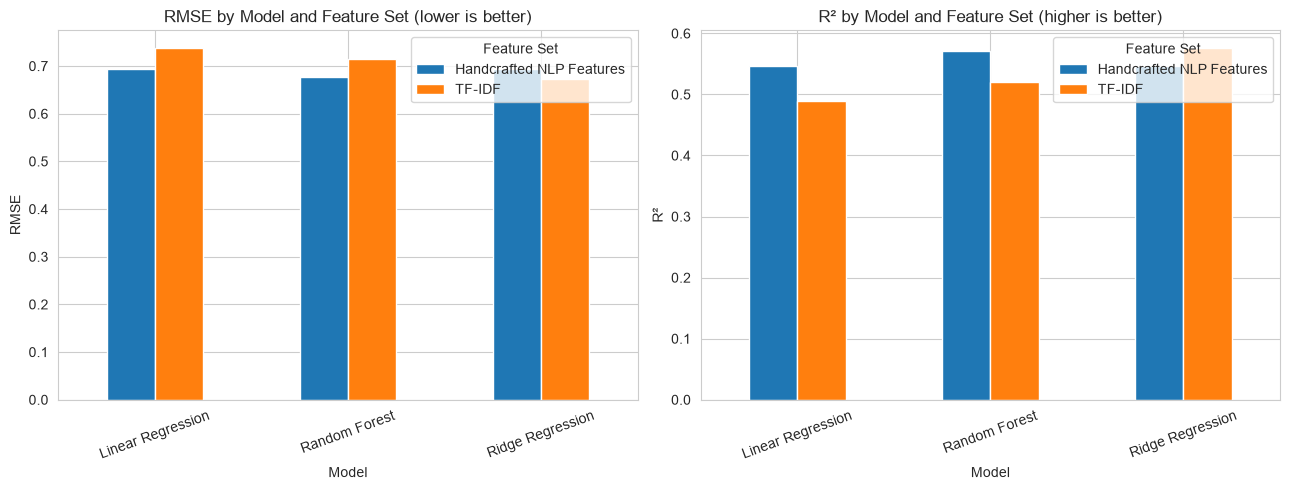

In [9]:
# Visual comparison of baseline regression models

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RMSE comparison
pivot_rmse = all_results.pivot(
    index='Model',
    columns='Feature Set',
    values='RMSE'
)

pivot_rmse.plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('RMSE by Model and Feature Set (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=20)

# R2 comparison
pivot_r2 = all_results.pivot(
    index='Model',
    columns='Feature Set',
    values='R2'
)

pivot_r2.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title('R² by Model and Feature Set (higher is better)')
axes[1].set_ylabel('R²')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()

plt.savefig(
    f'{FIG_DIR}/08_regression_model_comparison.png',
    bbox_inches='tight'
)

plt.show()


In [10]:
all_results.to_csv(
    f'{METRICS_DIR}/regression_results.csv',
    index=False
)

print(
    'Saved regression comparison table to '
    'results/metrics/regression_results.csv'
)


Saved regression comparison table to results/metrics/regression_results.csv


## 6. Secondary classification experiment — Low / Medium / High (Review 1 — Step 8/13)

**This is a separate, clearly-labeled demonstration.** The main essay-scoring system remains the
regression models above. A confusion matrix is a classification tool and does not apply to raw
regression output, so we bucket the essay scores into three categories using the project's
`add_score_category_column()` function and train a simple classifier for the confusion-matrix
requirement.

The classification experiment is **secondary**; it does not replace the primary regression task.


In [11]:
# Create Low / Medium / High categories for the secondary
# classification experiment only.

train_df_cat = add_score_category_column(train_df)
test_df_cat = add_score_category_column(test_df)

print('Category counts (train):')
print(train_df_cat['score_category'].value_counts().sort_index())

print('\nCategory counts (test):')
print(test_df_cat['score_category'].value_counts().sort_index())


Category counts (train):
score_category
High       1247
Low        6845
Medium    11690
Name: count, dtype: int64

Category counts (test):
score_category
High       309
Low       1753
Medium    2884
Name: count, dtype: int64


In [12]:
y_train_cat = train_df_cat['score_category']
y_test_cat = test_df_cat['score_category']

# Reuse the already-fitted TF-IDF features.
# No new fitting is performed on the test set.
clf = get_baseline_classifier(RANDOM_STATE)

clf, clf_train_time = train_and_time(
    clf,
    X_train_tfidf,
    y_train_cat
)

y_pred_cat = clf.predict(X_test_tfidf)

clf_metrics = classification_metrics(
    y_test_cat,
    y_pred_cat
)

clf_metrics['Training Time (s)'] = clf_train_time

display(pd.DataFrame([clf_metrics]))


,Accuracy,Precision,Recall,F1,Training Time (s)
0,0.7505,0.7515,0.7505,0.7357,2.064


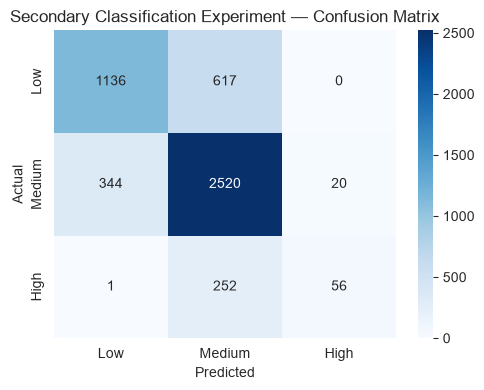

In [13]:
labels = ['Low', 'Medium', 'High']

cm = plot_confusion_matrix(
    y_test_cat,
    y_pred_cat,
    labels,
    title='Secondary Classification Experiment — Confusion Matrix',
    save_path=f'{FIG_DIR}/09_confusion_matrix.png'
)


**How to read this in the viva:** the confusion matrix rows are the true category, columns are
the predicted category. Strong diagonal values = correct predictions. Off-diagonal values show where
the classifier confuses adjacent categories (e.g. Medium predicted as Low) — expected, since the
underlying scale is continuous and the category boundaries are artificial cut points we imposed only
for this demonstration.

## 7. Final model comparison (Review 1 — Step 10)

**Regression (the real task):** ranked by RMSE (lower is better) — NOT by accuracy, which does not
apply to regression.

**Classification (secondary demonstration only):** reported separately, never mixed into the
regression comparison.

In [14]:
print('=== PRIMARY TASK: Regression — ranked by RMSE ===')

regression_ranking = all_results.sort_values(
    'RMSE',
    ascending=True
).reset_index(drop=True)

display(regression_ranking)

best_row = regression_ranking.iloc[0]

print(
    f"\nBest baseline: {best_row['Model']} "
    f"on {best_row['Feature Set']} "
    f"(RMSE={best_row['RMSE']:.4f}, "
    f"R²={best_row['R2']:.4f})"
)


=== PRIMARY TASK: Regression — ranked by RMSE ===


,Feature Set,Model,MAE,MSE,RMSE,R2,Training Time (s)
0,TF-IDF,Ridge Regression,0.5348,0.4516,0.6720,0.5760,0.475
1,Handcrafted NLP Features,Random Forest,0.5103,0.4571,0.6761,0.5709,1.621
2,Handcrafted NLP Features,Ridge Regression,0.5259,0.4823,0.6945,0.5472,0.004
3,Handcrafted NLP Features,Linear Regression,0.5259,0.4823,0.6945,0.5472,0.010
4,TF-IDF,Random Forest,0.5669,0.5115,0.7152,0.5198,382.625
5,TF-IDF,Linear Regression,0.5868,0.5442,0.7377,0.4891,3.658



Best baseline: Ridge Regression on TF-IDF (RMSE=0.6720, R²=0.5760)


In [15]:
print('=== SECONDARY EXPERIMENT: Classification (Low/Medium/High) ===')

clf_metrics_df = pd.DataFrame([clf_metrics])

display(clf_metrics_df)


=== SECONDARY EXPERIMENT: Classification (Low/Medium/High) ===


,Accuracy,Precision,Recall,F1,Training Time (s)
0,0.7505,0.7515,0.7505,0.7357,2.064


In [16]:
clf_metrics_df.to_csv(
    f'{METRICS_DIR}/classification_results.csv',
    index=False
)

print(
    'Saved classification metrics to '
    'results/metrics/classification_results.csv'
)


Saved classification metrics to results/metrics/classification_results.csv


## 8. Summary — what to say in the viva

- The primary task is regression: predicting the numeric `score`. Three baselines were trained on
  two feature representations (TF-IDF and handcrafted NLP features), evaluated with MAE/MSE/RMSE/R².
- The best baseline is chosen by RMSE (or R²) — never by "accuracy," since that metric doesn't apply
  to regression.
- A confusion matrix was produced only inside a clearly-separate secondary classification experiment
  (Low/Medium/High buckets), exactly to satisfy that specific checklist item — it does not replace or
  get mixed into the main regression pipeline.
- TF-IDF was fit strictly on training data and only *transformed* on the test set, avoiding data
  leakage — the same discipline was applied to the handcrafted feature scaler.
- All metrics and figures are saved under `results/metrics/` and `results/figures/`, ready to drop
  into the Review 1 report or slides.

**This completes the Review 1 checklist end-to-end** — dataset understanding, EDA, preprocessing,
baseline models, evaluation, confusion matrix (where applicable), and model comparison. No frontend,
backend, or LSTM work is included here — that's explicitly out of scope until after this review.